In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Variables

In [2]:
BUS_HEADWAY = 10  # minutes

COST_VRM = 15.96 # $/mile
# Convert to euros per km
COST_VRM_EURO = COST_VRM * 0.86406 / 1.60934  # euro/km
print(f"COST_VRM_EURO: {COST_VRM_EURO:.2f} euro/km")

COST_VRM_EURO: 8.57 euro/km


In [3]:
# Read PT scenario level results
pt_sce_res_df = pd.read_csv(os.path.join("data/pt-sim-results", "all_pt_scenario_level_analysis_results.csv"))

# Bus

In [4]:
# Basic Bus
trip_distance_basic_bus = 5  # km

num_trips_per_hour_basic_bus_we = 12
num_trips_per_hour_basic_bus_sn = 12

total_cost_per_hour_basic_bus_we = (trip_distance_basic_bus * num_trips_per_hour_basic_bus_we) * COST_VRM_EURO
total_cost_per_hour_basic_bus_sn = (trip_distance_basic_bus * num_trips_per_hour_basic_bus_sn) * COST_VRM_EURO
total_cost_per_hour_basic_bus = total_cost_per_hour_basic_bus_we + total_cost_per_hour_basic_bus_sn
print(f"Total cost per hour basic bus: {total_cost_per_hour_basic_bus:.2f} euro/hour")

Total cost per hour basic bus: 1028.28 euro/hour


In [5]:
# Ring Bus
trip_distance_ring_bus = 12 # km

num_trips_per_hour_ring_bus_0 = 6
num_trips_per_hour_ring_bus_1 = 6

total_cost_per_hour_ring_bus_0 = (trip_distance_ring_bus * num_trips_per_hour_ring_bus_0) * COST_VRM_EURO
total_cost_per_hour_ring_bus_1 = (trip_distance_ring_bus * num_trips_per_hour_ring_bus_1) * COST_VRM_EURO
total_cost_per_hour_ring_bus = total_cost_per_hour_ring_bus_0 + total_cost_per_hour_ring_bus_1
print(f"Total cost per hour ring bus: {total_cost_per_hour_ring_bus:.2f} euro/hour")

Total cost per hour ring bus: 1233.93 euro/hour


In [6]:
# Diagonal Bus
trip_distance_diagonal_bus = 10 # km

num_trips_per_hour_diagonal_bus_0 = 12
num_trips_per_hour_diagonal_bus_1 = 12

total_cost_per_hour_diagonal_bus_0 = (trip_distance_diagonal_bus * num_trips_per_hour_diagonal_bus_0) * COST_VRM_EURO
total_cost_per_hour_diagonal_bus_1 = (trip_distance_diagonal_bus * num_trips_per_hour_diagonal_bus_1) * COST_VRM_EURO
total_cost_per_hour_diagonal_bus = total_cost_per_hour_diagonal_bus_0 + total_cost_per_hour_diagonal_bus_1
print(f"Total cost per hour diagonal bus: {total_cost_per_hour_diagonal_bus:.2f} euro/hour")

Total cost per hour diagonal bus: 2056.55 euro/hour


# PT

In [9]:
# Basic
basic_pt_cost = 3 * (total_cost_per_hour_basic_bus)
print(f"Total Basic PT Cost: {basic_pt_cost:.2f}")

# Ring
ring_pt_cost = 3 * (total_cost_per_hour_ring_bus + total_cost_per_hour_basic_bus)
print(f"Total Ring PT Cost: {ring_pt_cost:.2f}")

# Diagonal
diagonal_pt_cost = 3 * (total_cost_per_hour_diagonal_bus + total_cost_per_hour_basic_bus)
print(f"Total Diagonal PT Cost: {diagonal_pt_cost:.2f}")

# Mature
mature_pt_cost = 3 * (total_cost_per_hour_ring_bus + total_cost_per_hour_diagonal_bus + total_cost_per_hour_basic_bus)
print(f"Total Mature PT Cost: {mature_pt_cost:.2f}")

# Write PT costs to scenario level results dataframe
pt_costs = {
    'basic': basic_pt_cost,
    'ring': ring_pt_cost,
    'diagonal': diagonal_pt_cost,
    'mature': mature_pt_cost
}
pt_sce_res_df['total_pt_cost'] = pt_sce_res_df['pt_network_name'].map(pt_costs)
# Save
pt_sce_res_df.to_csv(os.path.join("data/pt-sim-results", "all_pt_scenario_level_analysis_results.csv"), index=False)

Total Basic PT Cost: 3084.83
Total Ring PT Cost: 6786.63
Total Diagonal PT Cost: 9254.50
Total Mature PT Cost: 12956.29


# AMoD

In [7]:
# Read the analysis results
amod_results_dirpath = "data/amod-sim-results/"
amod_scenarios_results = pd.read_csv(os.path.join(amod_results_dirpath, "all_amod_scenario_level_analysis_results.csv"))

In [8]:
amod = amod_scenarios_results.copy()

# Aggregate irrelevant columns
amod = amod.groupby([
    'fleet_size',
    'broker_type',
]).agg({
    'total_amod_cost': 'mean',
}).reset_index()

# Rearrange columns
amod = amod.pivot_table(
    index=['fleet_size'],
    columns='broker_type',
    values=['total_amod_cost']
)

amod.columns = [f"{val[0]}_{val[1]}" for val in amod.columns]

amod = amod.reset_index()

# Convert cent to euro
amod['total_amod_cost_TPCS'] = amod['total_amod_cost_TPCS'] / 100
amod['total_amod_cost_default'] = amod['total_amod_cost_default'] / 100

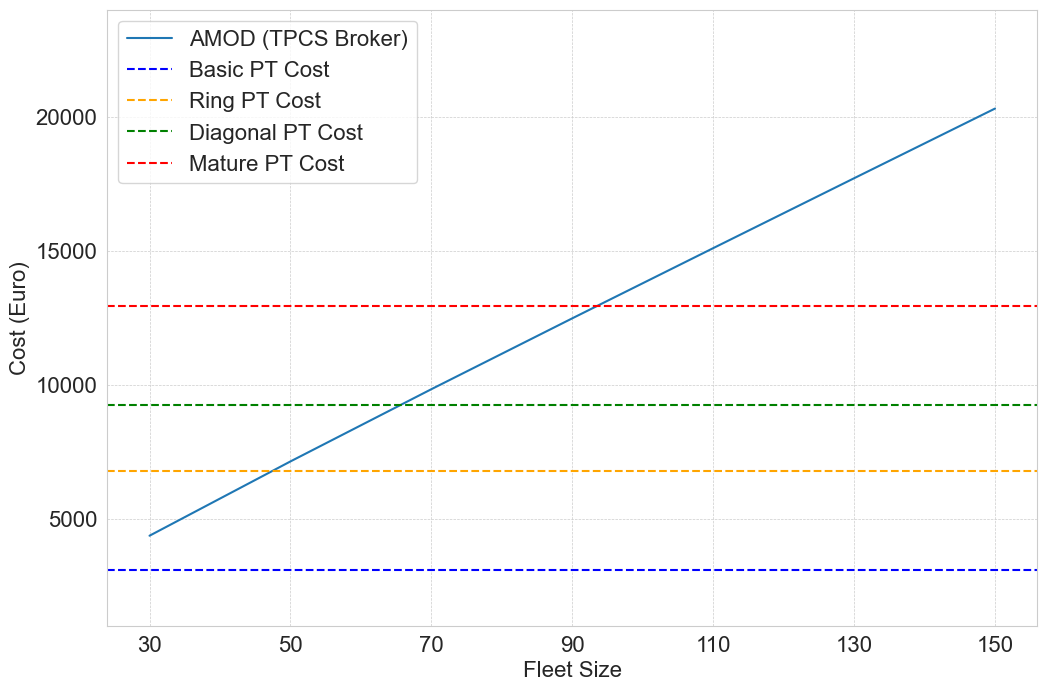

In [10]:
variable_name = 'fleet_size'
kpi = 'total_amod_cost_TPCS'
y_axis_limit = (1000, 24000)

plt.figure(figsize=(12, 8))

sns.set_style("whitegrid")

sns.lineplot(
    data=amod,
    x=variable_name,
    y=kpi,
    markers=True,
    dashes=False,
    errorbar=('ci', 95),
    label='AMOD (TPCS Broker)',
)

# Add baseline PT cost lines
plt.axhline(y=basic_pt_cost, color='blue', linestyle='--', label='Basic PT Cost')
plt.axhline(y=ring_pt_cost, color='orange', linestyle='--', label='Ring PT Cost')
plt.axhline(y=diagonal_pt_cost, color='green', linestyle='--', label='Diagonal PT Cost')
plt.axhline(y=mature_pt_cost, color='red', linestyle='--', label='Mature PT Cost')

plt.ylim(y_axis_limit)
x_ticks_to_show = sorted(amod[variable_name].unique())
plt.xticks(x_ticks_to_show)
plt.legend(fontsize=16)
plt.tick_params(labelsize=16)
plt.xlabel('Fleet Size', fontsize=16)
plt.ylabel('Cost (Euro)', fontsize=16)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()